# Noise-diode drift calibration (naive)

Anchor-free version: no cross-pointing pairs, no cross-pol bridge, no
per-pointing `T_B` differentiation.  We assume a single global sky-brightness
constant `T_B_ASSUMED` and compute `Tcal_pol(t, X)` per visit directly from the
radiometer + frequency-switching identities.

## Pipeline overview

| Sec | Step | Output |
|-----|------|--------|
| 1 | Load raw dumps (recal pointings only) | `recal_records` |
| 2 | fftshift + per-pol RFI flag + outlier-dump filter | cleaned `recal_records` |
| 3 | Build LO1/LO2 overlap grid + `INT_MASK` (DC bin excluded) | `INT_MASK` |
| 4 | Cluster dumps into visits; band-average to per-(pol, LO) scalars with SEM | `gain_visits` |
| 5 | Display `T_sys(t)` using nominal `T_cal` per pol (diagnostic only) | `tsys_df` |
| 6 | Attach per-pol scalar `R = (p_off^LO1 - p_off^LO2)/p_off^LO2` to each visit | `gain_visits[*]['R_pol{0,1}']` |
| 7 | Naive `Tcal_pol(t, X) = T_B_ASSUMED * (dp/poff) / R` per visit, plot | figure only |

## Naive calibration identity

For each visit, both polarisations independently:

```
R(t, X)        = (p_off^LO1 - p_off^LO2) / p_off^LO2     ~  dT_HI / T_sys_true(t)
dp/poff(t, X)  = (p_on - p_off) / p_off                  ~  Tcal_true(t) / T_sys_true(t)

T_sys_naive(t, X) = T_B_ASSUMED / R(t, X)                ~  T_B_ASSUMED * T_sys_true / dT_HI
Tcal_naive(t, X)  = T_sys_naive * dp/poff                ~  T_B_ASSUMED * Tcal_true / dT_HI
```

If the radiometer + constant-`T_B` picture holds, `Tcal_naive(t)` is **constant
in time at each pointing**, with a per-pointing offset proportional to
`T_B_ASSUMED / dT_HI_X` -- i.e. tracks at the two recal pointings should each be
flat but sit at different levels reflecting their actual HI line brightness
difference.  Any time variation is signal of model breakdown (true diode drift,
elevation-varying `T_B`, RFI inside `INT_MASK`, etc.).

## Explicit assumptions

- **Gain cancels.** Common-mode receiver gain `G(t)` cancels in both `R` and
  `dp/poff`, so the formula is gain-drift-invariant.
- **Constant `T_B` per pointing.** Recal targets are sidereally tracked at fixed
  (RA, Dec), so the integrated line brightness over `INT_MASK` is constant
  across visits.  Failure mode: elevation-varying continuum + ground spillover.
- **HI line carries `R`.** `dT_HI` (frequency-switched sky difference) is the
  dominant contribution to `(p_off^LO1 - p_off^LO2)`.  If RFI or
  bandpass-mismatch baselines dominate instead, `R` does not scale with
  `1/T_sys` and the cancellation breaks.
- **`T_B_ASSUMED` is a stipulation.** It sets the absolute scale of the y-axis
  (in K) but does not affect the *shape* of `Tcal_naive(t)`.  Use a literature
  HI brightness for the recal field or any convenient placeholder.

## Known limitations

1. **Per-pointing offset.** With a single global `T_B_ASSUMED`, the two
   pointings' tracks sit at levels proportional to `1/dT_HI_X`.  Their ratio is
   the diagnostic for differential line brightness, not for diode drift.
2. **No error propagation across pointings.** Each visit's SEM is tracked, but
   no inter-visit constraint enforces diode continuity.
3. **Absolute scale arbitrary.** Until tied to a known extended object, only
   *relative* drift within each pointing's track is meaningful.


In [1]:
import sys
import datetime as dt
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import astropy.units as u
import astropy.coordinates as ac
from astropy.time import Time

# Path: labs/04 (for utils/) and project root (for ugradiolab/).
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
_PROJECT_ROOT = str(Path.cwd().parent.parent)
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

from utils import (
    load_recal_dumps,
    build_session_summary,
    preprocess_dumps,
    flag_outlier_dumps,
    build_overlap_grid,
)
# Importing ugradiolab.plotting sets matplotlib rcParams globally
# (text.usetex=True, font sizes, tick directions, grid on by default).
from ugradiolab.plotting import (
    TEXTWIDTH_IN, textwidth_figure, subpanels, zero_line,
    LW_FINE, LW_LIGHT, ALPHA_FAINT, ALPHA_LIGHT, ALPHA_STANDARD,
    SS_STANDARD,
    NEUTRAL_COLOR, GRID_STYLE, GUIDE_STYLE, MODEL_STYLE,
)

# --- Hardware / signal-processing constants ---
SAMPLE_RATE_HZ = 3.2e6
NFFT = 1024
F1_MHZ = 1419.86
F2_MHZ = 1421.14
INT_TIME_S = 1025 * 16384 / SAMPLE_RATE_HZ  # ~5.25 s

# --- RFI channel flagger (applied to both pols) ---
RFI_WINDOW = 15
RFI_SIGMA = 10.0
RFI_CHEB_DEGREE = 3
RFI_SAMPLE_FRAC = 0.7
RFI_EXTREMA_ORDER = 2

# --- Outlier dump filter ---
SHAPE_DEV_THRESH = 0.05
SHAPE_FRAC_THRESH = 0.05
SHAPE_MIN_GROUP_SIZE = 3

# --- Frequency switching ---
EDGE_TRIM_MHZ = 0.256

# --- Visit clustering / calibration ---
VISIT_GAP_SEC = 300.0
# Nominal noise-diode temperatures (used to define the anchor T_sys).
# pol 0 = corr00, pol 1 = corr11.
T_CAL_NOMINAL = {0: 58.0, 1: 79.0}
POLS = (('corr00', 0), ('corr11', 1))
LOS = ((1, F1_MHZ), (2, F2_MHZ))

# --- Paths / display ---
DATA_DIRS = [Path('data/main'), Path('data/nps')]
# Recal pointings -> sky coordinates (from scripts/main/_survey.py).
POINTING_LABELS = {
    'recal_drift':    r'$(\alpha,\delta)=(180^\circ,\,72^\circ)$',
    'recal_drift_bk': r'$(\alpha,\delta)=(90^\circ,\,72^\circ)$',
}
# Session-shading style: one flat light alpha for all spans, with
# slightly deeper grey vertical lines at each session boundary.
SESSION_SPAN_ALPHA = 0.08
SESSION_BOUNDARY_ALPHA = 0.45
SESSION_BOUNDARY_COLOR = '0.35'


def _tex_safe(s):
    """Escape underscores for text.usetex=True string rendering."""
    return s.replace('_', r'\_')


def _shade_sessions(ax, session_spans):
    """Light flat-alpha shading per session + deeper boundary vlines."""
    boundaries = set()
    for t0, t1 in session_spans.values():
        ax.axvspan(t0, t1, color=NEUTRAL_COLOR,
                   alpha=SESSION_SPAN_ALPHA, zorder=0)
        boundaries.add(t0)
        boundaries.add(t1)
    for t in boundaries:
        ax.axvline(t, color=SESSION_BOUNDARY_COLOR,
                   alpha=SESSION_BOUNDARY_ALPHA,
                   lw=LW_FINE, zorder=1)


# --- Time-axis helpers: bottom = LST, top = PDT ---
# Leuschner Observatory (lat, lon, height).
LEUSCHNER_LOC = ac.EarthLocation(lat=37.9183*u.deg, lon=-122.1067*u.deg,
                                 height=304*u.m)
PDT_TZ = dt.timezone(dt.timedelta(hours=-7), name='PDT')


def _fmt_lst(unix_t):
    """LST (HH:MM) at Leuschner for a unix timestamp."""
    lst_h = Time(unix_t, format='unix',
                 location=LEUSCHNER_LOC).sidereal_time('apparent').hour
    lst_h = float(lst_h) % 24.0
    h = int(lst_h)
    m = int(round((lst_h - h) * 60))
    if m == 60:
        h, m = (h + 1) % 24, 0
    return f'{h:d}h {m:02d}m'


def _fmt_pdt(unix_t):
    """PDT timestamp (MM-DD HH:MM) for a unix timestamp."""
    return dt.datetime.fromtimestamp(unix_t, PDT_TZ).strftime('%m-%d %H:%M')


SIDEREAL_RATE = 1.00273790935        # LST hours per UT hour
SIDEREAL_DAY_S = 86400.0 / SIDEREAL_RATE
SOLAR_DAY_S = 86400.0

LST_TICK_HOURS = (0, 6, 12, 18)
PDT_TICK_HOURS = (0, 6, 12, 18)


def _lst_hour(unix_t):
    """LST in hours at Leuschner for a unix timestamp."""
    return float(Time(unix_t, format='unix',
                      location=LEUSCHNER_LOC)
                 .sidereal_time('apparent').hour) % 24.0


def _ticks_at_lst(t_lo, t_hi, target_hours):
    """All unix times in [t_lo, t_hi] where LST hits each target hour."""
    lst0 = _lst_hour(t_lo)
    ticks = []
    for target in target_hours:
        # Step in UT-seconds needed to advance LST from lst0 to target.
        delta_lst = (target - lst0) % 24.0
        t_first = t_lo + (delta_lst / SIDEREAL_RATE) * 3600.0
        t = t_first
        while t <= t_hi:
            ticks.append(t)
            t += SIDEREAL_DAY_S
    return sorted(ticks)


def _ticks_at_pdt(t_lo, t_hi, target_hours):
    """All unix times in [t_lo, t_hi] where PDT wall-clock hits each target hour."""
    ticks = []
    for target in target_hours:
        # unix t for PDT 00:00 of the local day containing t_lo, then step daily.
        day0 = dt.datetime.fromtimestamp(t_lo, PDT_TZ).replace(
            hour=0, minute=0, second=0, microsecond=0)
        t_target = (day0 + dt.timedelta(hours=target)).timestamp()
        while t_target < t_lo:
            t_target += SOLAR_DAY_S
        while t_target <= t_hi:
            ticks.append(t_target)
            t_target += SOLAR_DAY_S
    return sorted(ticks)


def time_axes_lst_pdt(axes):
    """Bottom axis (axes[-1]) labelled LST at {0,6,12,18}h; top axis
    (twinned on axes[0]) labelled PDT at {00:00, 06:00, 12:00, 18:00}.

    `axes` is the stacked-subplot array with sharex=True.  Both tick
    grids are computed from the actual x-limits, so multi-day spans get
    one tick per LST/PDT crossing.
    """
    bottom = axes[-1]
    t_lo, t_hi = bottom.get_xlim()

    lst_ticks = _ticks_at_lst(t_lo, t_hi, LST_TICK_HOURS)
    bottom.set_xticks(lst_ticks)
    bottom.set_xticklabels([f'{int(round(_lst_hour(t))) % 24:d}h'
                            for t in lst_ticks],
                           rotation=30, ha='right')
    bottom.set_xlabel('LST')

    top = axes[0].twiny()
    top.set_xlim(axes[0].get_xlim())
    pdt_ticks = _ticks_at_pdt(t_lo, t_hi, PDT_TICK_HOURS)
    top.set_xticks(pdt_ticks)
    top.set_xticklabels(
        [dt.datetime.fromtimestamp(t, PDT_TZ).strftime('%H:%M')
         for t in pdt_ticks],
        rotation=30, ha='left')
    top.set_xlabel('PDT')
    return top


/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load raw dumps (recal pointings)


In [2]:
recal_records = load_recal_dumps(DATA_DIRS)
sessions = sorted({r['session'] for r in recal_records})
pointings_seen = sorted({r['target_id'] for r in recal_records})

display(build_session_summary(recal_records, INT_TIME_S))
print(f'Recal: {len(recal_records)} dumps, {len(sessions)} sessions, '
      f'pointings: {pointings_seen}')


,Session,UTC Start,UTC End,Wall (min),Obs. Cells,Dumps,Duty %
0,main/session_001,2026-05-14 01:53,2026-05-14 02:43,50.2,1,48,8.4
1,nps/session_001,2026-05-14 02:56,2026-05-14 06:28,211.8,2,144,5.9
2,main/session_002,2026-05-14 07:29,2026-05-14 09:38,129.3,2,108,7.3
3,main/session_003,2026-05-14 09:38,2026-05-14 12:22,163.4,2,132,7.1
4,main/session_004,2026-05-14 12:25,2026-05-14 15:20,174.8,2,132,6.6
...,...,...,...,...,...,...,...
115,main/session_113,2026-05-18 14:32,2026-05-18 14:35,2.5,1,24,83.3
116,main/session_114,2026-05-18 14:35,2026-05-18 14:38,2.5,1,24,83.1
117,main/session_115,2026-05-18 14:38,2026-05-18 14:46,7.9,1,24,26.7
118,main/session_116,2026-05-18 14:47,2026-05-18 14:49,2.5,1,24,83.6


Recal: 6417 dumps, 120 sessions, pointings: ['recal_drift', 'recal_drift_bk']


## 2. fftshift + RFI flagging + outlier dump filter


In [3]:
n_rfi = preprocess_dumps(
    recal_records,
    rfi_window=RFI_WINDOW,
    rfi_sigma=RFI_SIGMA,
    rfi_degree=RFI_CHEB_DEGREE,
    rfi_sample_frac=RFI_SAMPLE_FRAC,
    rfi_extrema_order=RFI_EXTREMA_ORDER,
)
print(f'Recal: RFI flagged {n_rfi} channel samples '
      f'across {len(recal_records)} dumps (both pols)')

recal_out = flag_outlier_dumps(
    recal_records,
    dev_thresh=SHAPE_DEV_THRESH,
    frac_thresh=SHAPE_FRAC_THRESH,
    min_group_size=SHAPE_MIN_GROUP_SIZE,
)
print(f'Outlier dump filter: removed {len(recal_out)} recal '
      f'(>{SHAPE_FRAC_THRESH:.0%} channels deviate >{SHAPE_DEV_THRESH:.0%} from group median)')
print(f'Remaining: {len(recal_records)} recal dumps')


/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/joblib/memory.py:607: UserWarning: Persisting input arguments took 1.58s to run.If this happens often in your code, it can cause performance problems (results will be correct in all cases). The reason for this is probably some large input arguments for a wrapped function.
  return self._cached_call(args, kwargs, shelving=False)[0]


Recal: RFI flagged 44019 channel samples across 6417 dumps (both pols)
Outlier dump filter: removed 0 recal (>5% channels deviate >5% from group median)
Remaining: 6417 recal dumps


## 3. Frequency switching (overlap grid + integration mask)


In [4]:
grid = build_overlap_grid(
    F1_MHZ, F2_MHZ, SAMPLE_RATE_HZ, NFFT,
    edge_trim_mhz=EDGE_TRIM_MHZ,
)
overlap_mask = grid['overlap_mask']

INT_MASK = overlap_mask.copy()
INT_MASK[NFFT // 2] = False  # exclude DC bin
print(f'LO pair: ({F1_MHZ}, {F2_MHZ}) MHz')
print(f"Overlap: [{grid['f_overlap_lo']:.3f}, {grid['f_overlap_hi']:.3f}] MHz")
print(f'Integration mask: {INT_MASK.sum()} channels (DC excluded)')


LO pair: (1419.86, 1421.14) MHz
Overlap: [1419.796, 1421.201] MHz
Integration mask: 449 channels (DC excluded)


## 4. Per-visit band-averaged `p_on`, `p_off` (with SEM)


In [5]:
def _band_scalars(dumps, mask):
    """Per-dump band-average over `mask`; returns 1-D array of scalars."""
    if not dumps:
        return np.array([])
    return np.array([np.nanmean(d[mask]) for d in dumps])


def _mean_sem(scalars):
    """Visit mean and SEM = std(ddof=1)/sqrt(N) of per-dump scalars."""
    n = len(scalars)
    if n == 0:
        return np.nan, np.nan
    mu = float(np.nanmean(scalars))
    if n < 2:
        return mu, np.nan
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        sigma = float(np.nanstd(scalars, ddof=1))
    return mu, sigma / np.sqrt(n)


def build_gain_visits(records, visit_gap_sec=VISIT_GAP_SEC):
    """Cluster recal dumps into visits; band-average each dump to a scalar
    and store the visit mean + SEM per (pol, LO).
    """
    groups = defaultdict(list)
    for r in records:
        groups[(r['session'], r['target_id'])].append(r)

    visits = []
    for (session, target_id), grp in groups.items():
        grp = sorted(grp, key=lambda r: r['time'])
        runs = [[grp[0]]]
        for r in grp[1:]:
            if r['time'] - runs[-1][-1]['time'] > visit_gap_sec:
                runs.append([r])
            else:
                runs[-1].append(r)

        for visit_idx, run in enumerate(runs):
            v = {
                'session': session,
                'target_id': target_id,
                'visit_idx': visit_idx,
                't_mid': float(np.mean([r['time'] for r in run])),
                'alt_mean': float(np.mean([r['alt'] for r in run])),
                'gl': run[0]['gl'],
                'gb': run[0]['gb'],
                'n_dumps': len(run),
            }
            for pol_key, pol_idx in POLS:
                for lo_id, lo_mhz in LOS:
                    on = [r[pol_key] for r in run
                          if r['noise_on'] and r['lo_mhz'] == lo_mhz]
                    off = [r[pol_key] for r in run
                           if not r['noise_on'] and r['lo_mhz'] == lo_mhz]
                    pon,  spon  = _mean_sem(_band_scalars(on,  INT_MASK))
                    poff, spoff = _mean_sem(_band_scalars(off, INT_MASK))
                    v[f'p_on_pol{pol_idx}_lo{lo_id}']   = pon
                    v[f'p_off_pol{pol_idx}_lo{lo_id}']  = poff
                    v[f'sp_on_pol{pol_idx}_lo{lo_id}']  = spon
                    v[f'sp_off_pol{pol_idx}_lo{lo_id}'] = spoff
                    v[f'n_on_pol{pol_idx}_lo{lo_id}']   = len(on)
                    v[f'n_off_pol{pol_idx}_lo{lo_id}']  = len(off)
            visits.append(v)
    return sorted(visits, key=lambda v: v['t_mid'])


gain_visits = build_gain_visits(recal_records)
print(f'{len(gain_visits)} visits total')
print('Per pointing:',
      {tid: sum(1 for v in gain_visits if v['target_id'] == tid)
       for tid in sorted({v["target_id"] for v in gain_visits})})

# Diagnostic: typical fractional SEM on band-averaged P_off.
sem_fracs = []
for v in gain_visits:
    for pol_idx in (0, 1):
        for lo_id, _ in LOS:
            p  = v[f'p_off_pol{pol_idx}_lo{lo_id}']
            sp = v[f'sp_off_pol{pol_idx}_lo{lo_id}']
            if np.isfinite(p) and np.isfinite(sp) and p > 0:
                sem_fracs.append(sp / p)
sem_fracs = np.asarray(sem_fracs)
print(f'Median fractional SEM on band-averaged P_off: '
      f'{np.nanmedian(sem_fracs)*100:.3f}%  '
      f'(IQR {np.nanpercentile(sem_fracs, 25)*100:.3f}-'
      f'{np.nanpercentile(sem_fracs, 75)*100:.3f}%)')


476 visits total
Per pointing: {'recal_drift': 284, 'recal_drift_bk': 192}
Median fractional SEM on band-averaged P_off: 0.035%  (IQR 0.024-0.049%)


## 5. T_sys(t) per pointing (display only, with nominal T_cal)


In [6]:
def _lo_combine(vals_sigmas):
    """Inverse-variance combine a list of (value, sigma) pairs."""
    vals = np.array([v for v, _ in vals_sigmas], dtype=float)
    sigs = np.array([s for _, s in vals_sigmas], dtype=float)
    good = np.isfinite(vals) & np.isfinite(sigs) & (sigs > 0)
    if not np.any(good):
        return np.nan, np.nan
    w = 1.0 / sigs[good]**2
    mu = float(np.sum(w * vals[good]) / np.sum(w))
    return mu, float(1.0 / np.sqrt(np.sum(w)))


def visit_tsys_lo(visit, pol_idx, lo_id, T_cal):
    """Per-LO scalar T_sys = T_cal * p_off / (p_on - p_off) with SEM.

    var_T = (T_cal/dp^2)^2 * (p_on^2 sp_off^2 + p_off^2 sp_on^2)
    """
    pon   = visit[f'p_on_pol{pol_idx}_lo{lo_id}']
    poff  = visit[f'p_off_pol{pol_idx}_lo{lo_id}']
    spon  = visit[f'sp_on_pol{pol_idx}_lo{lo_id}']
    spoff = visit[f'sp_off_pol{pol_idx}_lo{lo_id}']
    if not (np.isfinite(pon) and np.isfinite(poff)
            and np.isfinite(spon) and np.isfinite(spoff)):
        return np.nan, np.nan
    dp = pon - poff
    if dp <= 0:
        return np.nan, np.nan
    tsys = T_cal * poff / dp
    var  = (T_cal / dp**2)**2 * (pon**2 * spoff**2 + poff**2 * spon**2)
    return float(tsys), float(np.sqrt(var))


rows = []
for v in gain_visits:
    for pol_idx in (0, 1):
        T_cal = T_CAL_NOMINAL[pol_idx]
        per_lo = [visit_tsys_lo(v, pol_idx, lo_id, T_cal) for lo_id, _ in LOS]
        tsys, sigma_tsys = _lo_combine(per_lo)
        rows.append({
            'session': v['session'],
            'target_id': v['target_id'],
            'visit_idx': v['visit_idx'],
            't_mid': v['t_mid'],
            'pol': pol_idx,
            'tsys_lo1': per_lo[0][0], 'sigma_tsys_lo1': per_lo[0][1],
            'tsys_lo2': per_lo[1][0], 'sigma_tsys_lo2': per_lo[1][1],
            'tsys': tsys,             'sigma_tsys': sigma_tsys,
            'alt': v['alt_mean'],
        })
tsys_df = pd.DataFrame(rows)


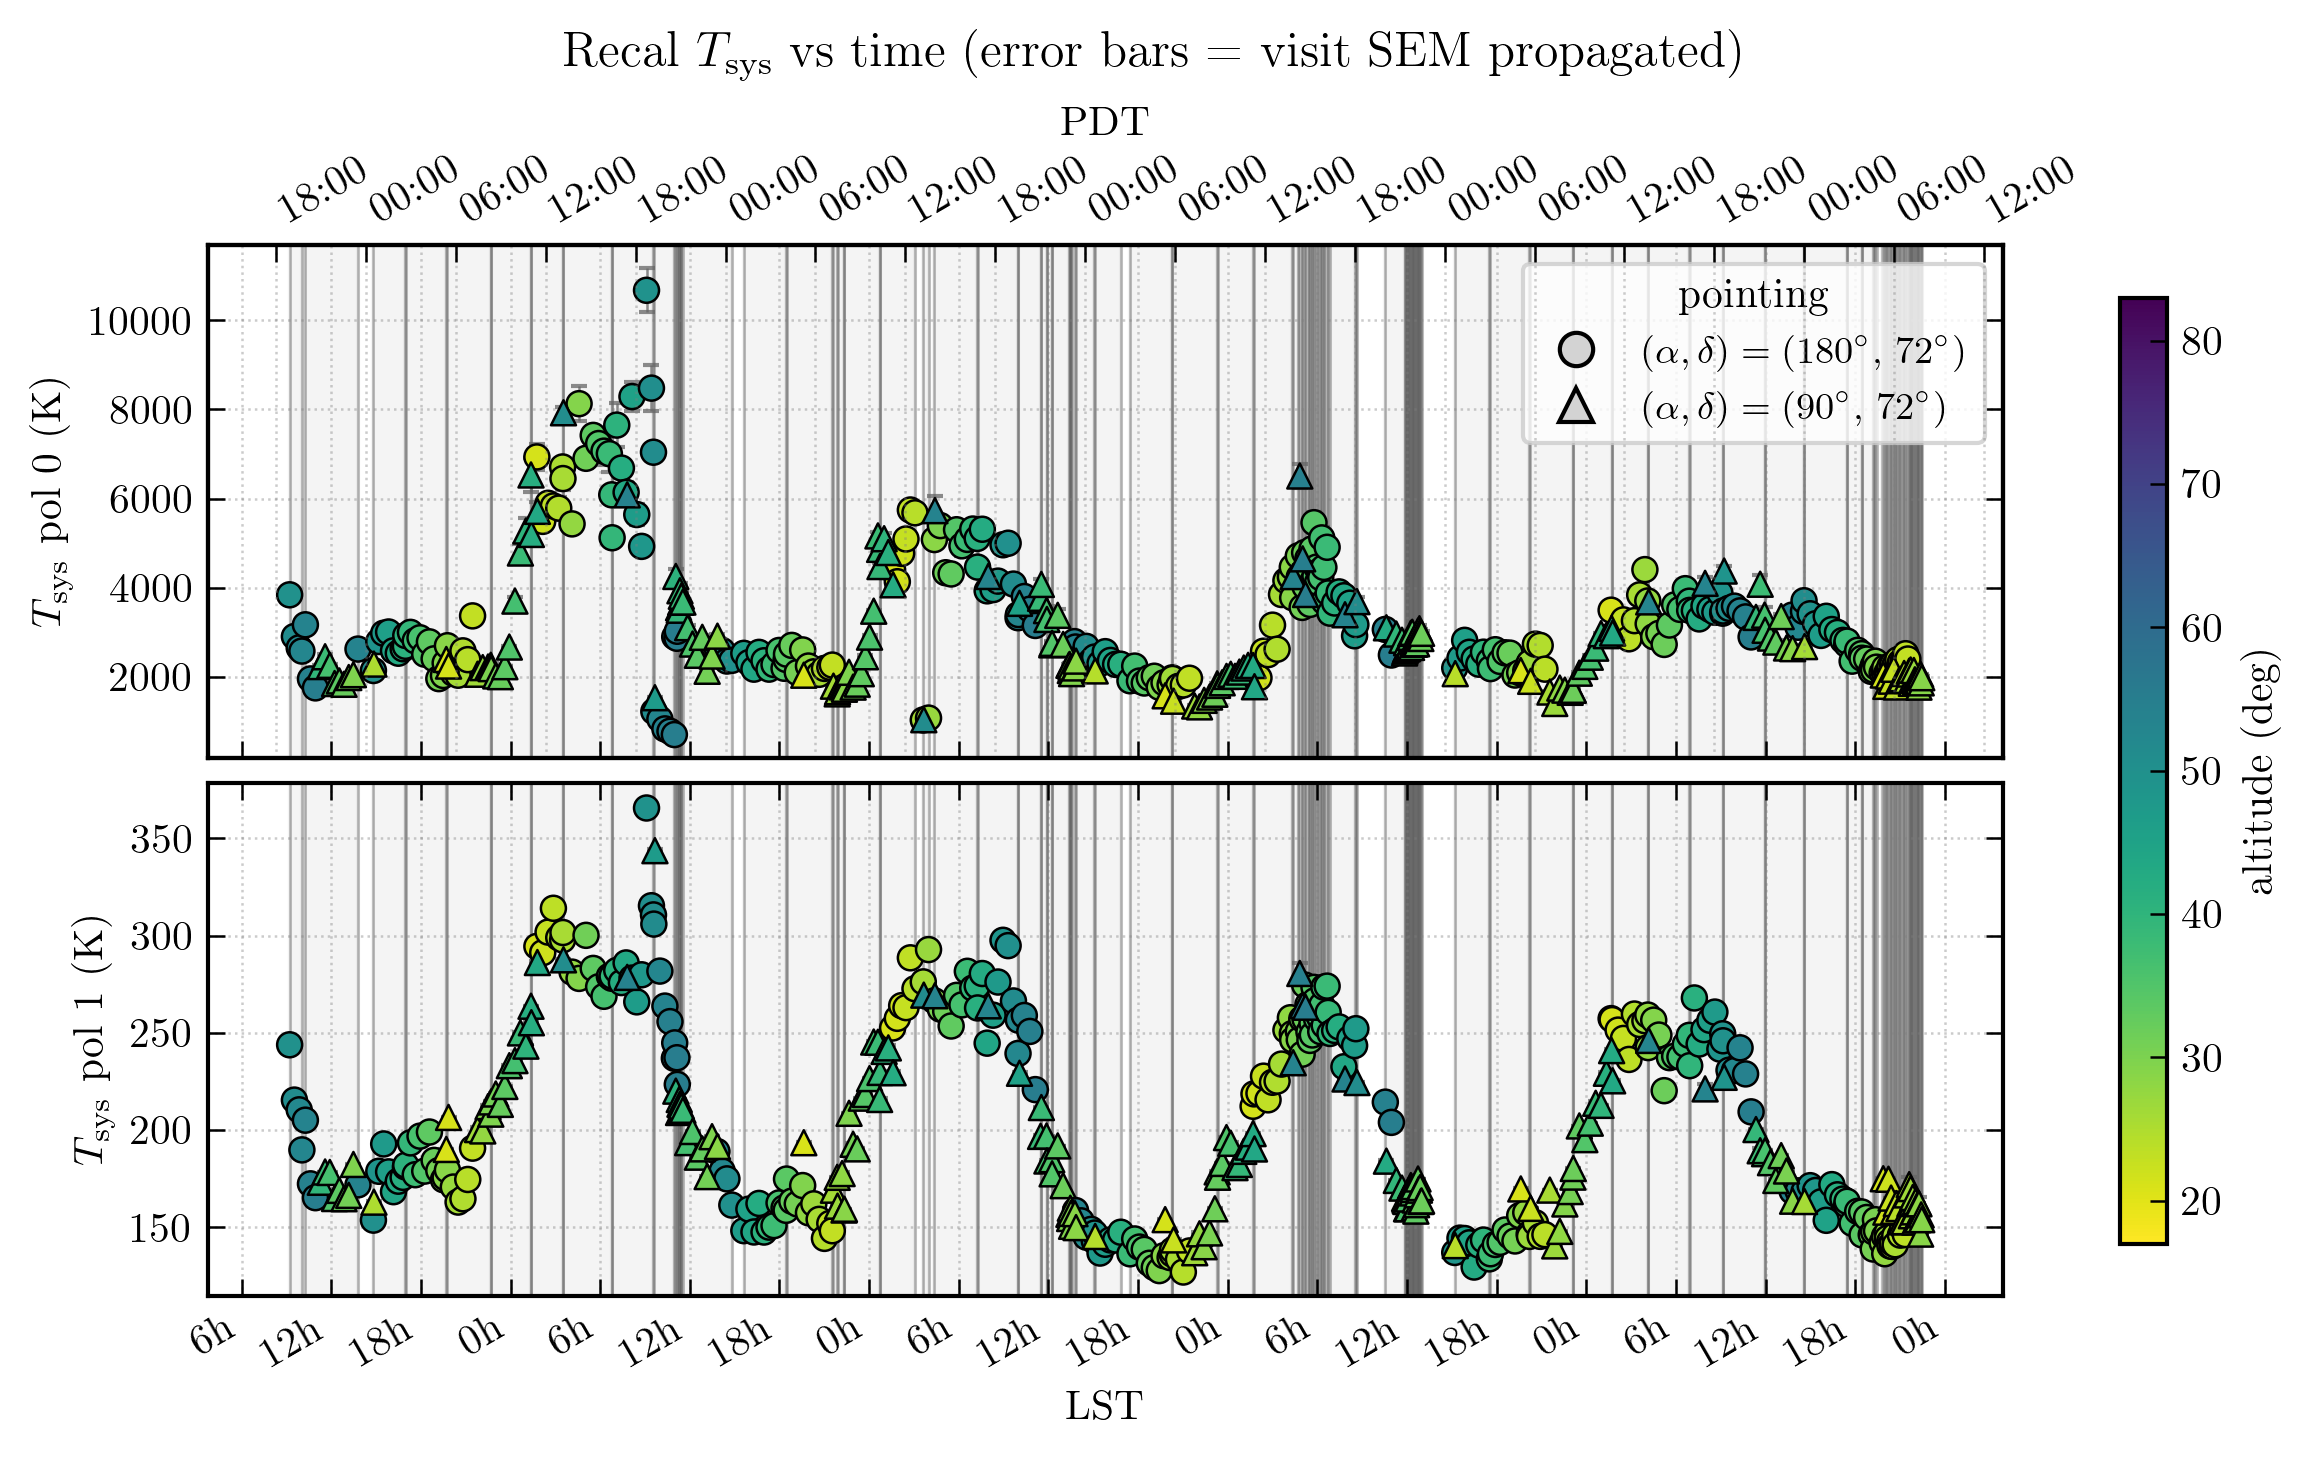

In [7]:
# Two stacked panels (pol 0 and pol 1), session-span shading,
# marker = pointing (circle vs triangle), face colour = altitude.
pointings = sorted(tsys_df['target_id'].unique())
markers = dict(zip(pointings, ['o', '^']))  # recal_drift -> circle, recal_drift_bk -> triangle

sessions = sorted(tsys_df['session'].unique())
session_spans = {
    s: (tsys_df.loc[tsys_df['session'] == s, 't_mid'].min(),
        tsys_df.loc[tsys_df['session'] == s, 't_mid'].max())
    for s in sessions
}

# Anchor colour scale to telescope altitude limits (Leuschner: 17-83 deg).
# Reversed viridis so brighter = lower altitude, darker = higher.
alt_min, alt_max = 17.0, 83.0
cmap = plt.cm.viridis_r

pt_colors = {tid: f'C{i}' for i, tid in enumerate(pointings)}

fig = plt.figure(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 10 / 16),
                 constrained_layout=True)
axes = subpanels(fig, 2, sharex=True)

sc = None
for ax, pol_idx in zip(axes, (0, 1)):
    _shade_sessions(ax, session_spans)
    for tid in pointings:
        sub = tsys_df[(tsys_df['pol'] == pol_idx) & (tsys_df['target_id'] == tid)]
        # SEM error bars (from per-channel propagation, weighted-mean reduced).
        ax.errorbar(sub['t_mid'], sub['tsys'], yerr=sub['sigma_tsys'],
                    fmt='none', ecolor='0.4', elinewidth=LW_FINE,
                    capsize=2, alpha=ALPHA_STANDARD, zorder=2)
        sc = ax.scatter(sub['t_mid'], sub['tsys'], c=sub['alt'],
                        cmap=cmap, vmin=alt_min, vmax=alt_max,
                        marker=markers[tid], s=SS_STANDARD,
                        edgecolor='k', linewidth=LW_FINE, zorder=3)
    ax.set_ylabel(rf'$T_{{\rm sys}}$ pol {pol_idx} (K)')

marker_handles = [
    Line2D([], [], marker=markers[tid], color='none',
           markerfacecolor='lightgray', markeredgecolor='k',
           markersize=8, label=POINTING_LABELS[tid])
    for tid in pointings
]
axes[0].legend(handles=marker_handles, loc='upper right', frameon=True,
               title='pointing')

time_axes_lst_pdt(axes)

cbar = fig.colorbar(sc, ax=axes, location='right',
                    fraction=0.04, pad=0.02, shrink=0.9)
cbar.set_label('altitude (deg)')

fig.suptitle(r'Recal $T_{\rm sys}$ vs time (error bars = visit SEM propagated)')
plt.show()

## 6. Per-pol scalar R at recal pointings


In [8]:
def add_per_pol_R(visits):
    """Scalar R_pol per visit per pol: R = (p_off_LO1 - p_off_LO2)/p_off_LO2.

    var_R = (sp1/p2)^2 + (p1 sp2 / p2^2)^2 by Gaussian propagation.
    """
    for v in visits:
        for pol_idx in (0, 1):
            p1, p2 = v[f'p_off_pol{pol_idx}_lo1'], v[f'p_off_pol{pol_idx}_lo2']
            s1, s2 = v[f'sp_off_pol{pol_idx}_lo1'], v[f'sp_off_pol{pol_idx}_lo2']
            if not (np.isfinite(p1) and np.isfinite(p2)
                    and np.isfinite(s1) and np.isfinite(s2)) or p2 == 0:
                v[f'R_pol{pol_idx}']  = np.nan
                v[f'sR_pol{pol_idx}'] = np.nan
                continue
            v[f'R_pol{pol_idx}'] = float((p1 - p2) / p2)
            var_R = (s1 / p2)**2 + (p1 * s2 / p2**2)**2
            v[f'sR_pol{pol_idx}'] = float(np.sqrt(var_R))


add_per_pol_R(gain_visits)
print('Per-pol scalar R and sigma_R attached to all visits.')


Per-pol scalar R and sigma_R attached to all visits.


## 7. Naive Tcal(t) per pointing


Naive Tcal computed for 284 A visits and 192 B visits (T_B_ASSUMED = 100.0 K).


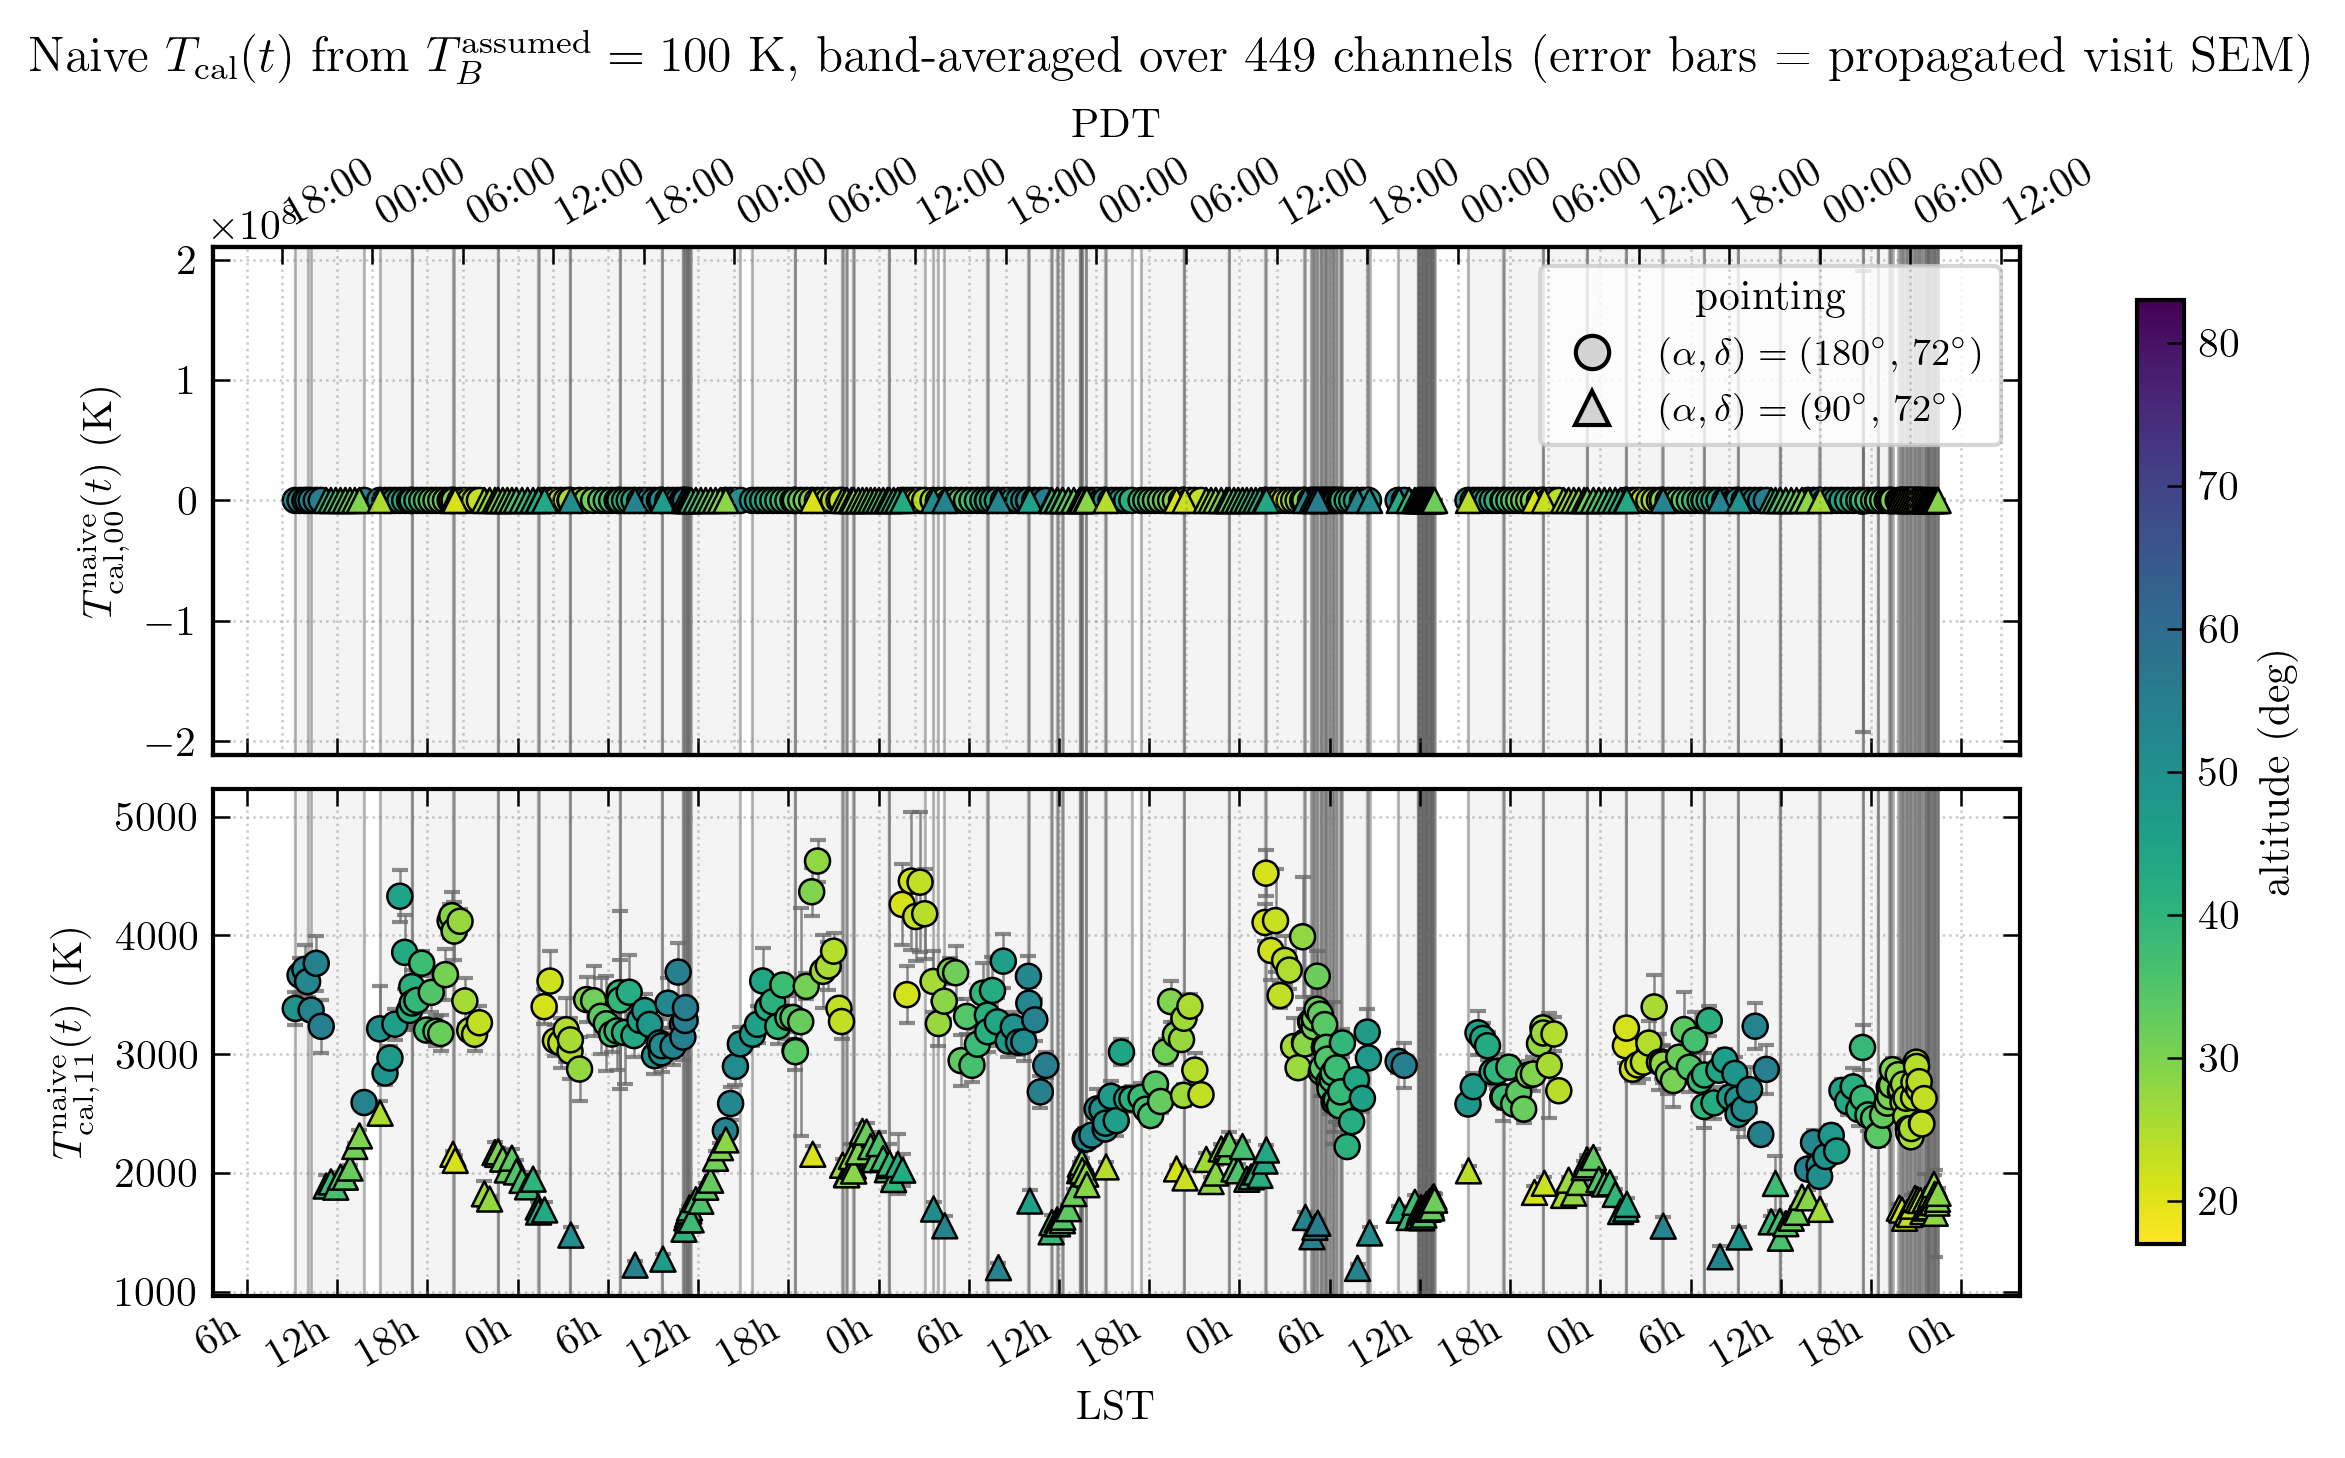

In [9]:
T_B_ASSUMED = 100.0  # K, single global sky-brightness stipulation (placeholder)


def visit_p_lo_avg(visit, pol_idx, kind):
    """LO-averaged scalar `p_{kind}` and its variance.

    var(p_avg) = sum(var_lo) / N_lo^2 assuming independent LO captures.
    """
    ps  = [visit[f'{kind}_pol{pol_idx}_lo{lo}']  for lo, _ in LOS]
    sps = [visit[f's{kind}_pol{pol_idx}_lo{lo}'] for lo, _ in LOS]
    pairs_ = [(p, s) for p, s in zip(ps, sps)
              if np.isfinite(p) and np.isfinite(s)]
    if not pairs_:
        return np.nan, np.nan
    p_avg = float(np.mean([p for p, _ in pairs_]))
    var   = float(np.sum([s**2 for _, s in pairs_])) / len(pairs_)**2
    return p_avg, var


def visit_dp_avg(visit, pol_idx):
    """LO-averaged scalar (p_on - p_off) and its variance."""
    pon,  von  = visit_p_lo_avg(visit, pol_idx, 'p_on')
    poff, voff = visit_p_lo_avg(visit, pol_idx, 'p_off')
    return pon - poff, von + voff


def compute_naive(visits, T_B_assumed):
    """Per-visit naive scalar Tcal with propagated SEM.

    Tcal_naive = T_B_assumed * (dp/poff) / R  for each pol, per visit.
    No anchoring, no cross-pol bridge, no per-pointing T_B differentiation.
    """
    rows = []
    for v in visits:
        row = {'t_mid': v['t_mid'], 'session': v['session'],
               'target_id': v['target_id'], 'alt': v['alt_mean']}
        for pol_idx in (0, 1):
            R, sR = v[f'R_pol{pol_idx}'], v[f'sR_pol{pol_idx}']
            poff, vpoff = visit_p_lo_avg(v, pol_idx, 'p_off')
            dp,   vdp   = visit_dp_avg(v, pol_idx)
            if (not np.isfinite(R) or R == 0
                    or not np.isfinite(poff) or poff == 0
                    or not np.isfinite(dp)):
                row[f'T_sys_pol{pol_idx}']       = np.nan
                row[f'sigma_T_sys_pol{pol_idx}'] = np.nan
                row[f'Tcal_pol{pol_idx}']        = np.nan
                row[f'sigma_Tcal_pol{pol_idx}']  = np.nan
                continue
            T_sys     = T_B_assumed / R
            var_Tsys  = T_sys**2 * (sR / R)**2

            Tcal     = T_sys * dp / poff
            var_Tcal = Tcal**2 * ((sR / R)**2
                                  + vdp / dp**2
                                  + vpoff / poff**2)

            row[f'T_sys_pol{pol_idx}']       = T_sys
            row[f'sigma_T_sys_pol{pol_idx}'] = float(np.sqrt(var_Tsys))
            row[f'Tcal_pol{pol_idx}']        = Tcal
            row[f'sigma_Tcal_pol{pol_idx}']  = float(np.sqrt(var_Tcal))
        rows.append(row)
    return pd.DataFrame(rows)


visits_A = sorted([v for v in gain_visits if v['target_id'] == pointings[0]],
                  key=lambda v: v['t_mid'])
visits_B = sorted([v for v in gain_visits if v['target_id'] == pointings[1]],
                  key=lambda v: v['t_mid'])
dfA_n = compute_naive(visits_A, T_B_ASSUMED)
dfB_n = compute_naive(visits_B, T_B_ASSUMED)
print(f'Naive Tcal computed for {len(dfA_n)} A visits and {len(dfB_n)} B visits '
      f'(T_B_ASSUMED = {T_B_ASSUMED:.1f} K).')

fig = plt.figure(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 10 / 16),
                 constrained_layout=True)
axes = subpanels(fig, 2, sharex=True)

sc = None
for ax, pol_idx in zip(axes, (0, 1)):
    _shade_sessions(ax, session_spans)
    for tid, df_pt in zip(pointings, (dfA_n, dfB_n)):
        ax.errorbar(df_pt['t_mid'], df_pt[f'Tcal_pol{pol_idx}'],
                    yerr=df_pt[f'sigma_Tcal_pol{pol_idx}'],
                    fmt='none', ecolor='0.4', elinewidth=LW_FINE,
                    capsize=2, alpha=ALPHA_STANDARD, zorder=2)
        sc = ax.scatter(df_pt['t_mid'], df_pt[f'Tcal_pol{pol_idx}'],
                        c=df_pt['alt'], cmap=cmap,
                        vmin=alt_min, vmax=alt_max,
                        marker=markers[tid], s=SS_STANDARD,
                        edgecolor='k', linewidth=LW_FINE, zorder=3)
    ax.set_ylabel(
        rf'$T_{{\rm cal,{pol_idx}{pol_idx}}}^{{\rm naive}}(t)$ (K)'
    )

marker_handles = [
    Line2D([], [], marker=markers[tid], color='none',
           markerfacecolor='lightgray', markeredgecolor='k',
           markersize=8, label=POINTING_LABELS[tid])
    for tid in pointings
]
axes[0].legend(handles=marker_handles, loc='upper right', frameon=True,
               title='pointing')

time_axes_lst_pdt(axes)

cbar = fig.colorbar(sc, ax=axes, location='right',
                    fraction=0.04, pad=0.02, shrink=0.9)
cbar.set_label('altitude (deg)')

fig.suptitle(
    rf'Naive $T_{{\rm cal}}(t)$ from $T_{{B}}^{{\rm assumed}}={T_B_ASSUMED:.0f}$ K, '
    rf'band-averaged over {INT_MASK.sum()} channels '
    rf'(error bars = propagated visit SEM)'
)
plt.show()


## 8. T_sys_A / T_sys_B ratio for near-simultaneous recal pairs

Pair every recal visit at pointing A with its nearest-in-time visit at pointing
B (uniquely matched, each B visit used at most once) within
`DT_MAX_PAIR = 600 s`.  Plot `T_sys_A(t_A) / T_sys_B(t_B)` vs the mean visit
time `t_mid = (t_A + t_B)/2` per pol, and overlay a fixed-`K = K_RATIO`
linear + Fourier fit (period = `SIDEREAL_DAY_S`).


pol 0: 53 pairs, <ratio>=0.883+/-0.003, K=3 chi2_r=106.52
pol 1: 53 pairs, <ratio>=0.972+/-0.000, K=3 chi2_r=263.58


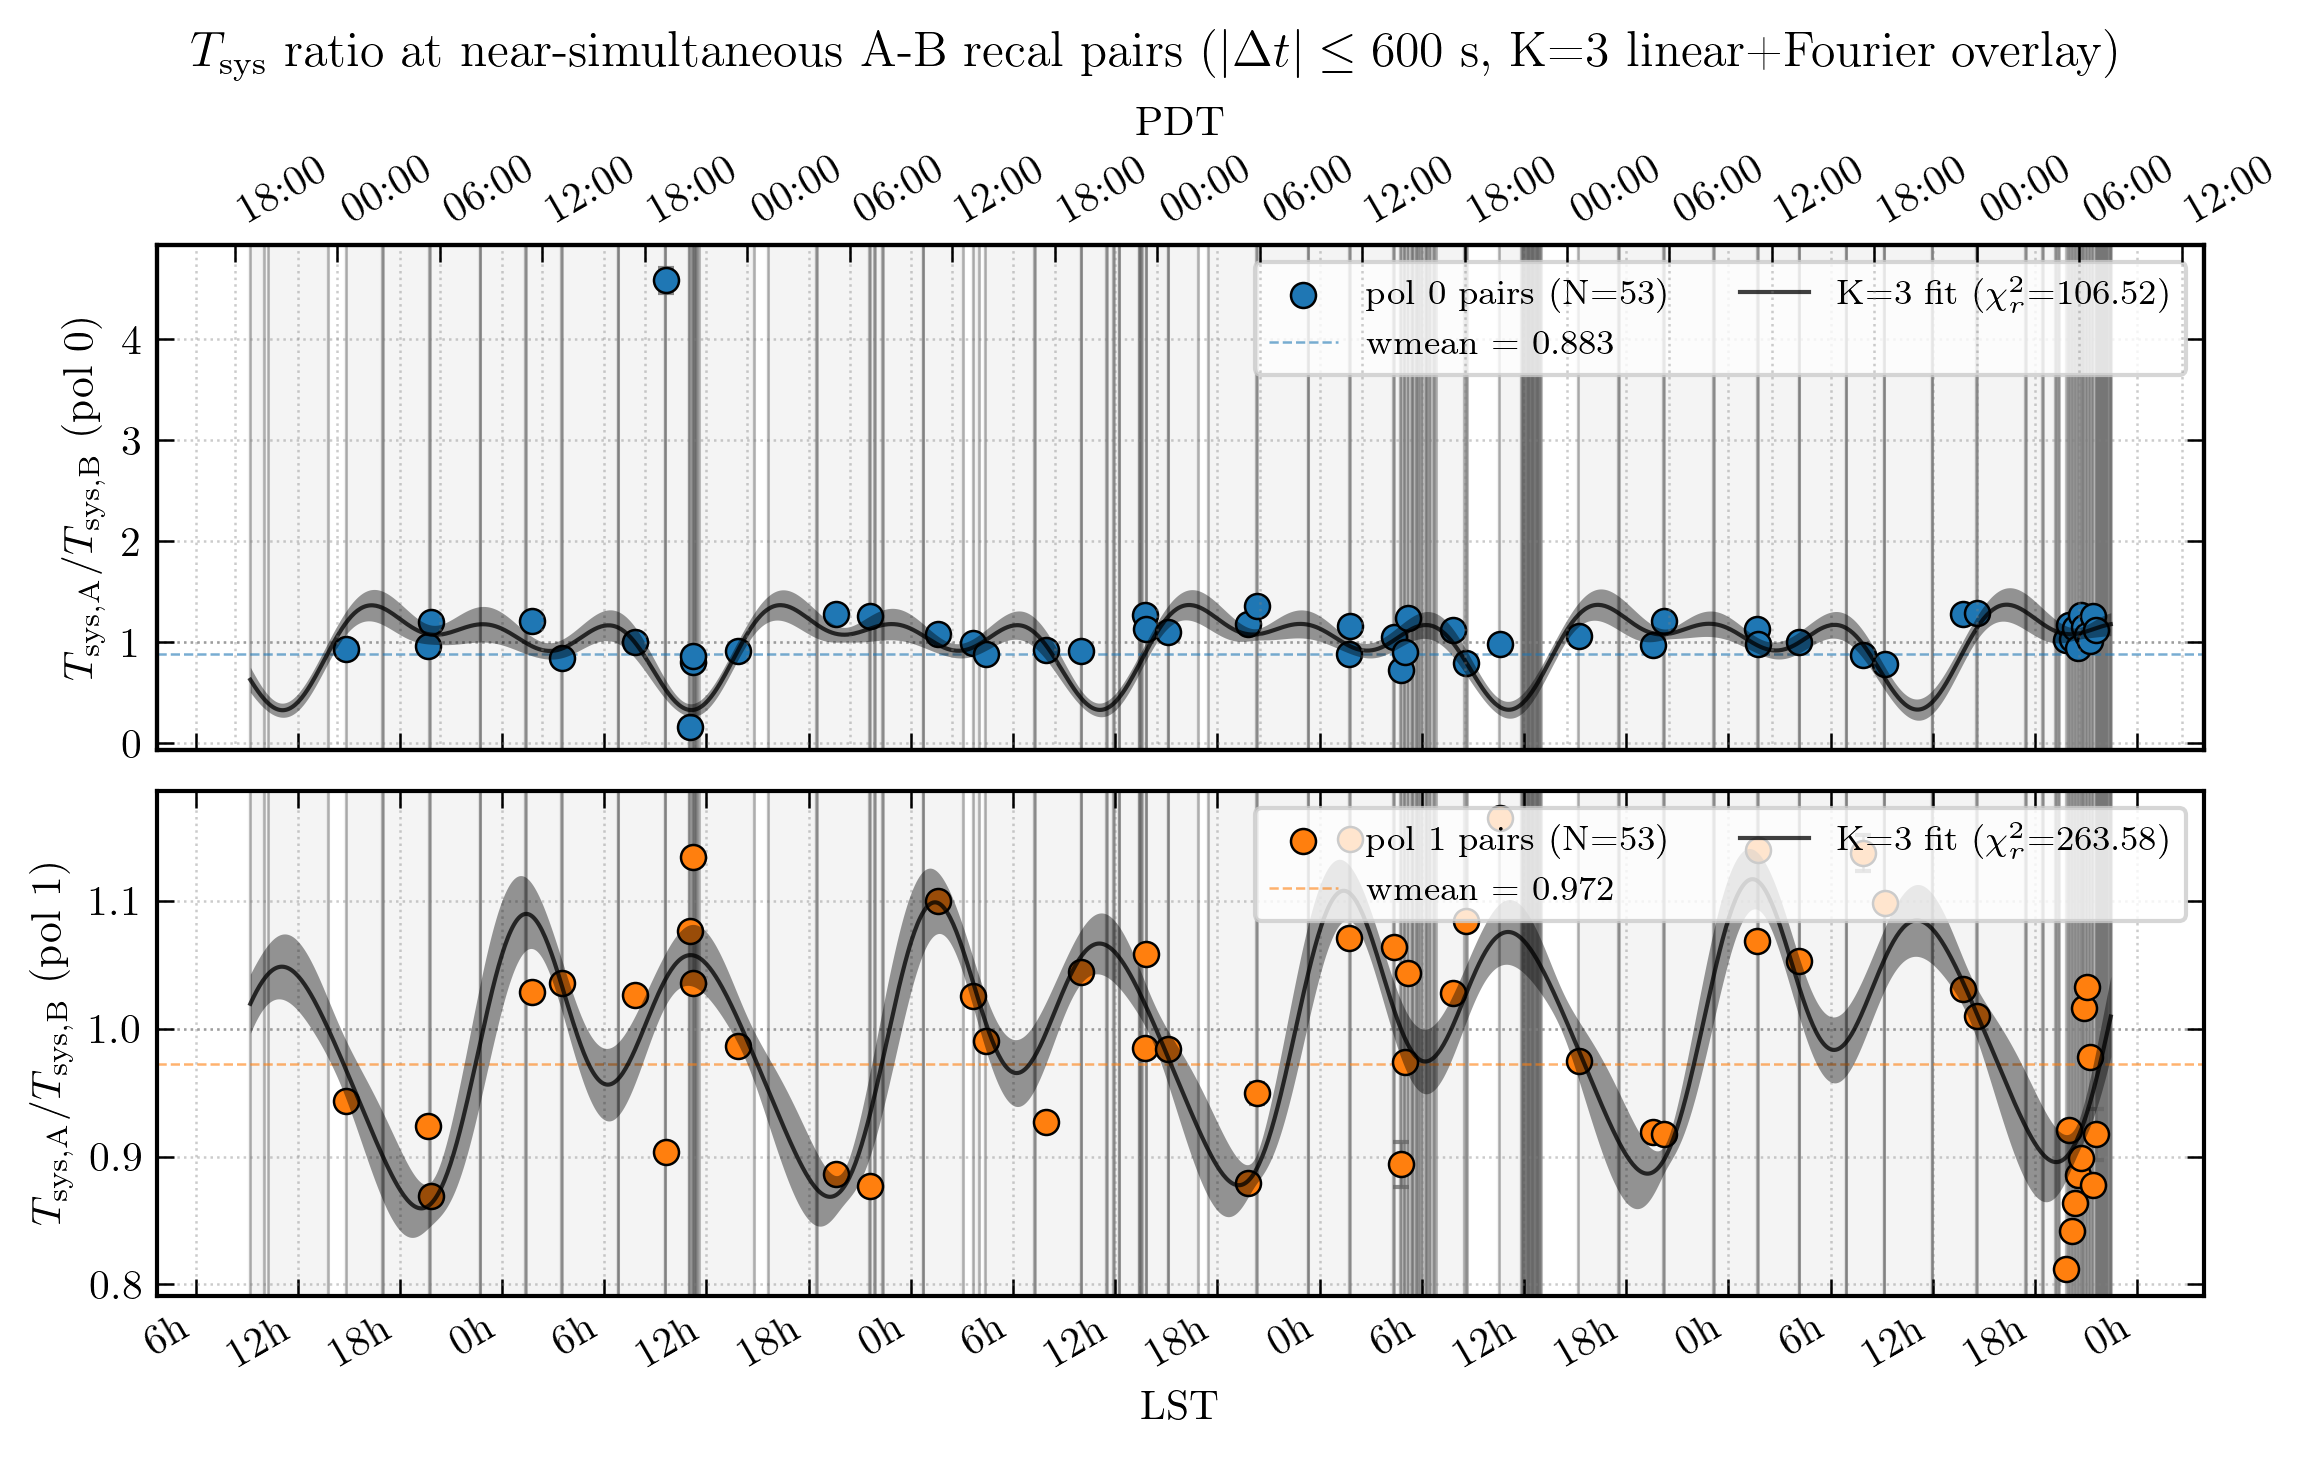

In [10]:
# --- Fourier machinery (linear + K-harmonic, period-aware) ---

PERIOD_S = SIDEREAL_DAY_S   # 24h LST = one sidereal day


def build_design_matrix(x, omega, k, x_ref=0.0, x_scale=1.0,
                        include_linear=True):
    """Design matrix: constant [+ linear in (x - x_ref)/x_scale] + Fourier.

    Fourier columns are phase-folded via x_mod = x % period for numerical
    stability at long baselines; the linear column uses raw x.
    """
    x = np.asarray(x, dtype=float)
    period = 2.0 * np.pi / omega
    x_mod = x % period
    n_extra = 1 if include_linear else 0
    X = np.ones((len(x_mod), 2 * k + 1 + n_extra), dtype=float)
    col = 1
    if include_linear:
        X[:, col] = (x - x_ref) / x_scale
        col += 1
    for j in range(1, k + 1):
        X[:, col]     = np.cos(j * omega * x_mod); col += 1
        X[:, col]     = np.sin(j * omega * x_mod); col += 1
    return X


def fourier_fit(x, y, y_err, period, k, include_linear=True):
    """Weighted LS fit; beta_cov inflated by max(chi2_r, 1)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y_err = np.asarray(y_err, dtype=float)
    n_params = 2 * k + 1 + (1 if include_linear else 0)
    if len(x) <= n_params:
        raise ValueError('Not enough data points for the requested model.')
    omega = 2.0 * np.pi / period
    x_ref = float(np.median(x))
    x_scale = float(np.std(x)) or 1.0
    X = build_design_matrix(x, omega, k, x_ref=x_ref, x_scale=x_scale,
                            include_linear=include_linear)
    w = 1.0 / y_err
    beta, *_ = np.linalg.lstsq(X * w[:, None], y * w, rcond=None)
    inv_var = 1.0 / np.square(y_err)
    normal = X.T @ (X * inv_var[:, None])
    beta_cov = np.linalg.inv(normal)
    resid = y - X @ beta
    nu = len(x) - n_params
    chi2_r = float(np.sum((resid / y_err) ** 2) / nu)
    beta_cov = beta_cov * max(chi2_r, 1.0)
    return {'period': period, 'omega': omega, 'k': k,
            'beta': beta, 'beta_cov': beta_cov,
            'chi2_r': chi2_r, 'n': len(x),
            'x_ref': x_ref, 'x_scale': x_scale,
            'include_linear': include_linear}


def _design_from_fit(fit, x):
    return build_design_matrix(x, fit['omega'], fit['k'],
                               x_ref=fit['x_ref'], x_scale=fit['x_scale'],
                               include_linear=fit['include_linear'])


def fourier_predict(fit, x):
    return _design_from_fit(fit, x) @ fit['beta']


def fourier_predict_std(fit, x):
    X = _design_from_fit(fit, x)
    pred_var = np.einsum('ij,jk,ik->i', X, fit['beta_cov'], X)
    return np.sqrt(np.clip(pred_var, 0.0, None))


# --- Pair-finding + ratio --------------------------------------------------

DT_MAX_PAIR = 600.0  # s
K_RATIO = 3


def _ratio_with_sigma(TA, sA, TB, sB):
    if not (np.isfinite(TA) and np.isfinite(TB)) or TB == 0:
        return np.nan, np.nan
    r = TA / TB
    var = r ** 2 * ((sA / TA) ** 2 + (sB / TB) ** 2)
    return r, float(np.sqrt(var))


tid_A, tid_B = pointings[0], pointings[1]
ratios_per_pol = {0: [], 1: []}

for pol_idx in (0, 1):
    sub = tsys_df[tsys_df['pol'] == pol_idx]
    rows_A = sub[sub['target_id'] == tid_A].sort_values('t_mid')
    rows_B = sub[sub['target_id'] == tid_B].sort_values('t_mid')
    used_B = set()
    for _, rA in rows_A.iterrows():
        cand = rows_B[~rows_B.index.isin(used_B)]
        if cand.empty:
            break
        dt_abs = (cand['t_mid'] - rA['t_mid']).abs()
        iB = dt_abs.idxmin()
        if dt_abs.loc[iB] > DT_MAX_PAIR:
            continue
        rB = cand.loc[iB]
        used_B.add(iB)
        r, sr = _ratio_with_sigma(rA['tsys'], rA['sigma_tsys'],
                                  rB['tsys'], rB['sigma_tsys'])
        if not (np.isfinite(r) and np.isfinite(sr)):
            continue
        ratios_per_pol[pol_idx].append({
            't_mid': 0.5 * (rA['t_mid'] + rB['t_mid']),
            'dt': float(rB['t_mid'] - rA['t_mid']),
            'ratio': r, 'sigma': sr,
        })

# K=K_RATIO linear + Fourier fit per pol
ratio_fits = {}
for pol_idx in (0, 1):
    pl = ratios_per_pol[pol_idx]
    n = len(pl)
    if n <= 2 * K_RATIO + 2:
        ratio_fits[pol_idx] = None
        print(f'pol {pol_idx}: {n} pairs, too few for K={K_RATIO}')
        continue
    t  = np.array([d['t_mid'] for d in pl])
    r  = np.array([d['ratio'] for d in pl])
    sr = np.array([d['sigma'] for d in pl])
    fit = fourier_fit(t, r, sr, PERIOD_S, K_RATIO, include_linear=True)
    ratio_fits[pol_idx] = fit
    w = 1.0 / sr ** 2
    wmean = float(np.sum(w * r) / np.sum(w))
    wsig  = float(1.0 / np.sqrt(np.sum(w)))
    print(f'pol {pol_idx}: {n} pairs, <ratio>={wmean:.3f}+/-{wsig:.3f}, '
          f'K={K_RATIO} chi2_r={fit["chi2_r"]:.2f}')

# Plot
fig = plt.figure(figsize=(TEXTWIDTH_IN, TEXTWIDTH_IN * 10 / 16),
                 constrained_layout=True)
axes = subpanels(fig, 2, sharex=True)

t_lo = float(tsys_df['t_mid'].min())
t_hi = float(tsys_df['t_mid'].max())
t_dense = np.linspace(t_lo, t_hi, 1200)

for ax, pol_idx in zip(axes, (0, 1)):
    _shade_sessions(ax, session_spans)
    pl = ratios_per_pol[pol_idx]
    if pl:
        ts = np.array([d['t_mid'] for d in pl])
        rs = np.array([d['ratio'] for d in pl])
        ss = np.array([d['sigma'] for d in pl])
        ax.errorbar(ts, rs, yerr=ss, fmt='none', ecolor='0.4',
                    elinewidth=LW_FINE, capsize=2,
                    alpha=ALPHA_STANDARD, zorder=2)
        ax.scatter(ts, rs, color=f'C{pol_idx}', s=SS_STANDARD,
                   edgecolor='k', linewidth=LW_FINE, zorder=3,
                   label=f'pol {pol_idx} pairs (N={len(pl)})')
        w = 1.0 / ss ** 2
        wmean = float(np.sum(w * rs) / np.sum(w))
        ax.axhline(wmean, color=f'C{pol_idx}', ls='--', lw=LW_FINE,
                   alpha=ALPHA_LIGHT, label=f'wmean = {wmean:.3f}')
        fit = ratio_fits[pol_idx]
        if fit is not None:
            mu = fourier_predict(fit, t_dense)
            sd = fourier_predict_std(fit, t_dense)
            ax.fill_between(t_dense, mu - sd, mu + sd,
                            color='k', alpha=ALPHA_FAINT,
                            linewidth=0, zorder=3.5)
            ax.plot(t_dense, mu, color='k', lw=LW_LIGHT,
                    alpha=ALPHA_STANDARD, zorder=4,
                    label=rf'K={K_RATIO} fit ($\chi^2_r$={fit["chi2_r"]:.2f})')
    ax.axhline(1.0, color='0.5', ls=':', lw=LW_FINE,
               alpha=ALPHA_LIGHT, zorder=1)
    ax.set_ylabel(rf'$T_{{\rm sys,A}}/T_{{\rm sys,B}}$ (pol {pol_idx})')
    ax.legend(loc='upper right', frameon=True, fontsize='small', ncol=2)

time_axes_lst_pdt(axes)
fig.suptitle(
    rf'$T_{{\rm sys}}$ ratio at near-simultaneous A-B recal pairs '
    rf'($|\Delta t| \leq {DT_MAX_PAIR:.0f}$ s, K={K_RATIO} linear+Fourier overlay)'
)
plt.show()
